In [3]:
import os, sys, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))

from augmented.core import mask_from_indices, mask_str
from augmented.bayesian import _poisson_binomial_pmf, bayesian_update_by_counting
from augmented.solver import solve_optimal_dapts
from augmented.greedy import greedy_myopic_expected_utility
from augmented.independence_gap import (
    exact_pool_pmf, independence_pool_pmf, gap_summary,
    run_experiment, aggregate,
    exact_greedy_myopic_expected_utility,
)
from augmented.rl_examples import (
    value_iteration, value_iteration_optimal_value,
    tabular_q_learning, q_learning_policy_value,
    _prior_weights, _cleared_utility, _transition,
)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (7, 4)


---

## Parte 1. La heurística de independencia

El greedy guarda las marginales posteriores `p̃ᵢ = P(Zᵢ=1 | H)` y
aproxima la probabilidad de que un pool `t` "limpie" (todos sanos)
como el producto:

$$P(r_t = 0 \mid H) \approx \prod_{i \in t}(1 - \tilde p_i).$$

Ese producto solo sería exacto si los `Zᵢ` fueran independientes
dado el historial. Las pruebas pasadas introducen correlación, así
que el producto puede equivocarse.


### Ejemplo 1 — el caso donde más se nota

Cuatro personas con prior `pᵢ = 0.5` cada una. Probamos el pool
`t' = {0,1}` y resulta `r' = 1` (exactamente uno de los dos está
infectado, pero no sabemos cuál). Ahora queremos puntuar el pool
grande `t = {0,1,2,3}`.

- Como al menos uno de `{0,1}` está infectado, `rₜ ≥ 1` siempre. Eso
  quiere decir que `P(rₜ = 0 | H) = 0` exactamente.
- Las marginales posteriores de `0` y `1` son `p̃₀ = p̃₁ = 0.5` (por
  simetría), así que la heurística da `0.5⁴ = 0.0625`.

Este es el patrón donde la heurística falla más: el historial
"amarra" miembros del pool sin forzar sus marginales a los extremos.


In [2]:
n = 4
p = [0.5] * n
history = ((mask_from_indices([0, 1]), 1),)
pool = mask_from_indices([0, 1, 2, 3])

exact = exact_pool_pmf(p, history, pool, n)
heur = independence_pool_pmf(p, history, pool, n)

df_pmf = pd.DataFrame({
    'r_t = k':        [f'k={k}' for k in range(n + 1)],
    'exacta':         [f'{v:.4f}' for v in exact],
    'heurística (indep)': [f'{v:.4f}' for v in heur],
})
print(df_pmf.to_string(index=False))

tv = 0.5 * sum(abs(a - b) for a, b in zip(exact, heur))
print(f'\nTV(exacta, heurística) = {tv:.4f}')
print(f'gap en r=0: heurística {heur[0]:.4f}  vs  exacta {exact[0]:.4f}')


r_t = k exacta heurística (indep)
    k=0 0.0000             0.0625
    k=1 0.2500             0.2500
    k=2 0.5000             0.3750
    k=3 0.2500             0.2500
    k=4 0.0000             0.0625

TV(exacta, heurística) = 0.1250
gap en r=0: heurística 0.0625  vs  exacta 0.0000


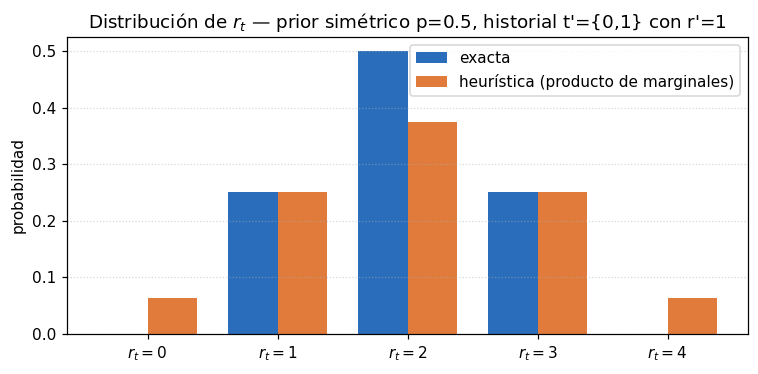

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(n + 1)
w = 0.38
ax.bar(x - w/2, exact, w, label='exacta', color='#2a6ebb')
ax.bar(x + w/2, heur,  w, label='heurística (producto de marginales)',
       color='#e07b3c')
ax.set_xticks(x)
ax.set_xticklabels([f'$r_t={k}$' for k in range(n + 1)])
ax.set_ylabel('probabilidad')
ax.set_title(f'Distribución de $r_t$ — prior simétrico p=0.5, historial t\'={{0,1}} con r\'=1')
ax.legend()
ax.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


### Ejemplo 2 — ¿qué tan frecuente es?

Generamos 200 instancias aleatorias (`n = 7`, `B = 3`, `G = 3`, priors
uniformes en `[0.05, 0.5]`), jugamos el historial con greedy myopic, y
para cada pool candidato de tamaño 2 o 3 comparamos la PMF exacta
(enumerando los `2ⁿ` mundos consistentes) con la heurística
Poisson-Binomial de las marginales.

> *Tarda ~30–60 segundos.*


In [4]:
t0 = time.time()
rows = run_experiment(n=7, B=3, G=3, num_instances=200, seed=0,
                      history_strategy='greedy')
summary = aggregate(rows)
print(f'{len(rows):,} filas totales — {time.time()-t0:.1f} s')
pd.DataFrame(summary).T[['count', 'tv_mean', 'tv_median', 'tv_p95',
                         'tv_max', 'abs_gap_r0_mean', 'abs_gap_rmax_mean']]


11,200 filas totales — 0.3 s


,count,tv_mean,tv_median,tv_p95,tv_max,abs_gap_r0_mean,abs_gap_rmax_mean
2,4200.0,0.030237,0.0,0.274034,0.499999,0.015119,0.015119
3,7000.0,0.061922,0.0,0.493585,0.554731,0.027882,0.012237


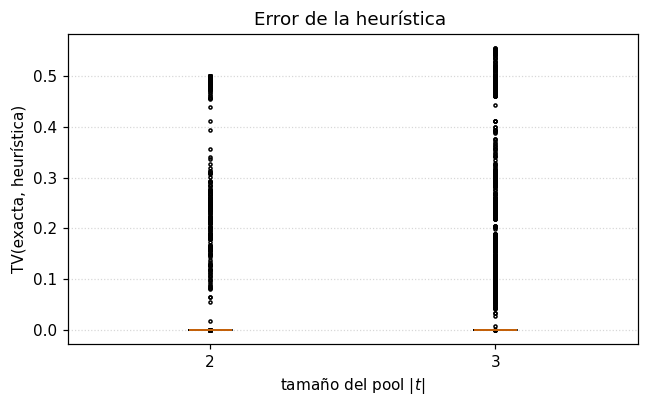

In [5]:
# Boxplot del TV por tamaño de pool
by_size = {}
for r in rows:
    by_size.setdefault(r['pool_size'], []).append(r['tv'])

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.boxplot([by_size[s] for s in sorted(by_size)],
           tick_labels=[str(s) for s in sorted(by_size)],
           showfliers=True, flierprops={'marker': '.', 'markersize': 4})
ax.set_xlabel('tamaño del pool $|t|$')
ax.set_ylabel('TV(exacta, heurística)')
ax.set_title('Error de la heurística ')
ax.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


### Ejemplo 3 — ¿arreglar la heurística mejora al greedy?

Una pregunta natural: si la heurística a veces se equivoca mucho,
¿qué pasa si la reemplazamos por el cálculo exacto `P(rₜ = 0 | H)`?
Esto es lo que hace `exact_greedy_myopic_expected_utility`: mismo
greedy myopic pero puntúa pools con la probabilidad exacta de limpiar.

Comparamos, sobre instancias aleatorias pequeñas:
- `heurístico`: greedy con `∏(1 - p̃ᵢ)` (la versión actual).
- `exacto`:    greedy con `P(rₜ = 0 | H)` (la versión con scoring exacto).
- `óptimo`:    el DP exacto (sin greedy).

Esperaría que el "exacto" esté siempre entre el heurístico y el óptimo,
pero veremos que **no siempre es el caso**.


In [6]:
rng = random.Random(0)
rows = []
for trial in range(40):
    n = rng.randint(3, 5)
    p = [rng.uniform(0.1, 0.5) for _ in range(n)]
    u = [rng.uniform(1, 3) for _ in range(n)]
    B = rng.randint(2, 3)
    G = rng.randint(2, n)

    opt, _ = solve_optimal_dapts(p, u, B, G)
    eu_heur = greedy_myopic_expected_utility(p, u, B, G)
    eu_exact = exact_greedy_myopic_expected_utility(p, u, B, G)

    rows.append({
        'n': n, 'B': B, 'G': G,
        'opt': opt, 'heur': eu_heur, 'exact': eu_exact,
        'heur_gap': opt - eu_heur,
        'exact_gap': opt - eu_exact,
    })

df_greedy = pd.DataFrame(rows)
print(df_greedy.describe()[['opt', 'heur', 'exact', 'heur_gap', 'exact_gap']])

wins_exact = (df_greedy['exact'] > df_greedy['heur'] + 1e-6).sum()
wins_heur  = (df_greedy['heur']  > df_greedy['exact'] + 1e-6).sum()
ties = len(df_greedy) - wins_exact - wins_heur
print(f'\nExacto gana: {wins_exact}   Heurístico gana: {wins_heur}   Empate: {ties}')


             opt       heur      exact      heur_gap     exact_gap
count  40.000000  40.000000  40.000000  4.000000e+01  4.000000e+01
mean    4.299362   4.116207   4.154630  1.831548e-01  1.447320e-01
std     1.079001   1.008846   1.029580  1.843459e-01  1.502228e-01
min     2.352599   2.253313   2.253313 -8.881784e-16 -4.440892e-16
25%     3.478910   3.320071   3.337503  4.086635e-02  4.916552e-02
50%     4.226485   4.000320   4.058082  9.776226e-02  9.652151e-02
75%     4.830790   4.784174   4.763385  2.764929e-01  1.746339e-01
max     7.160764   6.642522   6.686644  6.628159e-01  7.189582e-01

Exacto gana: 13   Heurístico gana: 7   Empate: 20


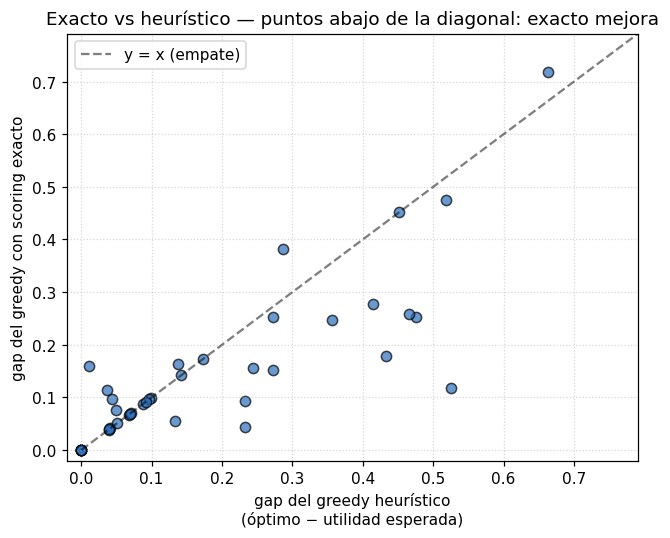

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_greedy['heur_gap'], df_greedy['exact_gap'],
           s=45, alpha=0.7, color='#2a6ebb', edgecolor='k')
lim = max(df_greedy['heur_gap'].max(), df_greedy['exact_gap'].max()) * 1.1
ax.plot([0, lim], [0, lim], 'k--', alpha=0.5, label='y = x (empate)')
ax.set_xlabel('gap del greedy heurístico\n(óptimo − utilidad esperada)')
ax.set_ylabel('gap del greedy con scoring exacto')
ax.set_title('Exacto vs heurístico — puntos abajo de la diagonal: exacto mejora')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xlim(-0.02, lim)
ax.set_ylim(-0.02, lim)
plt.tight_layout()
plt.show()


Arreglar el scoring no
es una solución mágica:

- En varios casos el exacto **sí** mejora (puntos debajo de la
  diagonal). Ahí la heurística estaba sesgando la decisión y corregirla
  acerca al óptimo.
- En otros casos el exacto **empeora** (puntos arriba de la diagonal).
  Esto pasa porque la decisión sigue siendo *de un solo paso* (greedy
  miope): al cambiar el score en un paso puede elegir un pool que
  acumula peor información para los pasos siguientes.
- En muchos casos los dos coinciden (la decisión de un paso resulta
  la misma con o sin corregir el score).

La conclusión matizada: la brecha matemática entre heurística y
exacta es real, pero el greedy de un paso tiene un techo fijo por
decidir mirando solo un paso. Corregir el score es una mejora
**local**; romper el techo requiere planeación **secuencial** — ver
varios pasos hacia adelante. Esto es justo lo que resuelve el
framework MDP de la segunda parte.


---

## Parte 2. DAPTS como MDP

Un **MDP** (*Markov Decision Process*) es un modelo con cuatro piezas:
el agente observa un **estado**, toma una **acción**, el mundo
transiciona a un nuevo estado según una probabilidad, y el agente
recibe una **recompensa**. El objetivo es maximizar la suma esperada
de recompensas a lo largo del horizonte.

Para DAPTS:

- **Estado** `s = (k, remaining, cleared)` — `k` tests usados,
  `remaining` = conjunto de perfiles `z` consistentes con el
  historial, `cleared` = individuos probados sanos.
- **Acción** `a` — un pool (subconjunto de `[n]` de tamaño `≤ G`).
- **Transición** — observamos `r = |a ∩ Z|`, nos quedamos con los `z`
  consistentes con `r`; si `r = 0`, agregamos `a` a `cleared`.
- **Recompensa** — `0` en pasos intermedios; al final, la utilidad de
  los individuos limpiados.

Con esta formulación, `V*(s₀)` es la utilidad esperada óptima. La
**ecuación de Bellman** dice cuánto vale un estado: el mejor valor
posible es la acción que da, en expectativa, el mejor valor futuro.

$$V^*(s) = \max_a \; \mathbb{E}[\, r(s,a,s') + V^*(s') \,].$$

Resolver esa ecuación hacia atrás (de `k = B` a `k = 0`) es lo que
hace *value iteration*. En nuestro caso, esto es **matemáticamente
idéntico** al DP exacto que ya tenemos; solo cambia el vocabulario.


### Ejemplo 4 — Bellman a mano en `n=2, B=1`

Dos personas con `p = (0.3, 0.4)`, `u = (1, 1)`, un solo test. Las
acciones posibles son `{}, {0}, {1}, {0,1}`.


In [8]:
n, B, G = 2, 1, 2
p = [0.3, 0.4]
u = [1.0, 1.0]

w = _prior_weights(p, n)
all_z = frozenset(range(1 << n))
total = sum(w[z] for z in all_z)

from augmented.core import all_pools
from augmented.independence_gap import _exact_best_pool  # unused, but keeps import clean

rows = []
for a in all_pools(n, G, include_empty=True):
    ev = 0.0
    parts = []
    for r, mass_r, new_rem, new_cl in _transition(all_z, 0, a, w):
        prob = mass_r / total
        util = _cleared_utility(new_cl, u, n)
        ev += prob * util
        parts.append(f'P(r={r})={prob:.2f} → limpia {mask_str(new_cl, n)} (u={util:.1f})')
    rows.append({'acción': mask_str(a, n), 'Q*(s0, a)': round(ev, 4),
                 'desglose': '; '.join(parts)})

pd.DataFrame(rows)


,acción,"Q*(s0, a)",desglose
0,{},0.00,P(r=0)=1.00 → limpia {} (u=0.0)
1,{0},0.70,P(r=0)=0.70 → limpia {0} (u=1.0); P(r=1)=0.30 ...
2,{1},0.60,P(r=0)=0.60 → limpia {1} (u=1.0); P(r=1)=0.40 ...
3,"{0,1}",0.84,"P(r=0)=0.42 → limpia {0,1} (u=2.0); P(r=1)=0.4..."


In [9]:
opt = value_iteration_optimal_value(p, u, B, G)
print(f'V*(s0) = max sobre acciones = {opt:.4f}')
print('(Probar a los dos juntos gana con 0.7·0.6·2 = 0.84)')


V*(s0) = max sobre acciones = 0.8400
(Probar a los dos juntos gana con 0.7·0.6·2 = 0.84)


### Ejemplo 5 — Value iteration vs DP exacto en `n=3, B=2`

El DP que ya tenemos (`solve_optimal_dapts`) es exactamente Bellman
hacia atrás sobre el mismo MDP. Los dos deben dar el mismo número.


In [10]:
p = [0.2, 0.3, 0.4]
u = [1.0, 2.0, 1.5]
B, G = 2, 3

opt_dp, _ = solve_optimal_dapts(p, u, B, G)
opt_vi = value_iteration_optimal_value(p, u, B, G)
print(f'DP exacto                   : {opt_dp:.8f}')
print(f'Value iteration sobre MDP   : {opt_vi:.8f}')
print(f'Diferencia                  : {abs(opt_dp - opt_vi):.2e}')


DP exacto                   : 2.65600000
Value iteration sobre MDP   : 2.65600000
Diferencia                  : 4.44e-16


### Ejemplo 6 — Q-learning tabular

Value iteration necesita conocer el modelo (probabilidades de
transición). **Q-learning** resuelve el mismo problema sin ese modelo:
aprende la función `Q(s, a)` (el valor esperado de tomar la acción
`a` en el estado `s`) solo jugando episodios. La idea:

1. Sampleamos un `z` verdadero del prior (el agente no lo ve).
2. Jugamos `B` tests con **ε-greedy**: con probabilidad `ε` probamos
   un pool al azar (*exploración*), si no, elegimos el que tiene `Q`
   más alto hasta el momento (*explotación*).
3. Al final actualizamos `Q(s, a)` hacia la utilidad obtenida
   (recompensa terminal), ajustando poco a poco con un peso
   `α = 1/(1+N(s,a))` (cuanto más hemos visitado el par, más pequeño
   el ajuste).

Con suficientes episodios, `Q` se acerca a los valores óptimos del
value iteration — pero es un proceso iterativo, no un cálculo
cerrado.


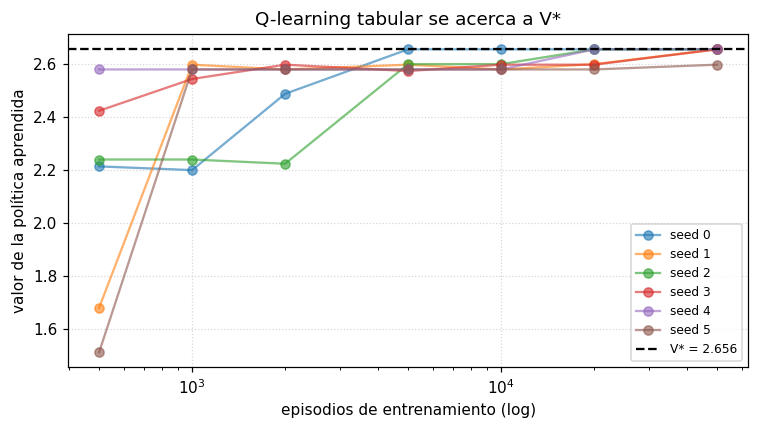

In [11]:
p = [0.2, 0.3, 0.4]
u = [1.0, 2.0, 1.5]
B, G = 2, 3
opt = value_iteration_optimal_value(p, u, B, G)

episode_counts = [500, 1000, 2000, 5000, 10000, 20000, 50000]
seeds = list(range(6))
curves = {s: [] for s in seeds}
for seed in seeds:
    for ep in episode_counts:
        Q = tabular_q_learning(p, u, B, G, num_episodes=ep,
                                epsilon=0.5, seed=seed)
        val = q_learning_policy_value(p, u, B, G, Q)
        curves[seed].append(val)

fig, ax = plt.subplots(figsize=(7, 4))
for seed, ys in curves.items():
    ax.plot(episode_counts, ys, marker='o', alpha=0.6, label=f'seed {seed}')
ax.axhline(opt, color='k', linestyle='--', label=f'V* = {opt:.3f}')
ax.set_xscale('log')
ax.set_xlabel('episodios de entrenamiento (log)')
ax.set_ylabel('valor de la política aprendida')
ax.set_title('Q-learning tabular se acerca a V*')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


La mayoría de seeds llegan al óptimo en ~20k episodios. Uno se
queda un 2% por debajo incluso con 50k — Q-learning tabular
**converge en el límite**, pero no "resuelve" el problema en un
número fijo de episodios. Es un método iterativo que se acerca.


---

## Conexión entre las dos partes

Un eje "conocimiento requerido vs precisión" ordena los métodos:

| Método                                      | Conocimiento             | Precisión                |
|---------------------------------------------|--------------------------|--------------------------|
| Heurística `∏(1 - p̃ᵢ)` (greedy actual)      | marginales `p̃ᵢ`          | aproximada               |
| Counting + greedy (Ejemplo 3)               | modelo completo          | score exacto, greedy     |
| Gibbs + greedy                              | modelo completo          | score aproximado, greedy |
| Value iteration / DP                        | modelo completo          | óptima                   |
| Q-learning tabular                          | solo interacción         | tiende al óptimo         |
| Q-learning + red neuronal                   | solo interacción         | aproximada (escalable)   |

## Próximos pasos

1. **Corregir el scoring del greedy puede ayudar, pero no siempre.**
   Conviene estudiar cuándo sí ayuda (régimen de priors, topología
   del historial) antes de reemplazar la heurística global.
2. **Lookahead myopic** — el *lookahead greedy* ya implementado gana
   sobre myopic por ver un paso más; combinar eso con scoring exacto
   puede cerrar más brecha.
3. **Adaptar PPO al setting aumentado** — reescribir el environment
   de `classical/rl_training/PPO_bucket_gymnasium_B*.py` con resultado
   `r = |t ∩ Z|` y update bayesiano por conteo, y entrenar para `n`
   grande donde el DP ya no cabe.

Los tests unitarios de todo esto están en
`augmented/tests.py` (prefijos `test_exact_pool_pmf_*`, `test_vi_*`,
`test_q_learning_*`, `test_exact_greedy_*`).
